# Distribution of the error on differet code sizes

**Introduced noise**
- $\alpha$: zero that become non-zero (0->d)
- $\beta$: non-zero that become zero (d->0)

**Metrics**
- **Empirical $\alpha$ (Alpha):** Calculated as:
  $$\alpha_{emp} = \frac{\text{Count of } 0 \to \text{Non-Zero changes}}{\text{Total number of original } 0\text{s}}$$
  It measures the accuracy of the noise generator for zero entries.
- **Empirical $\beta$ (Beta):** Calculated as:
  $$\beta_{emp} = \frac{\text{Count of Non-Zero } \to 0 \text{ changes}}{\text{Total number of original Non-Zeros}}$$
  It measures the rate of "erasure" of the monomial signal.
- **Visual Volume ($\text{vol\_alpha/beta}$):** Calculated as:
  $$\text{Volume} = \frac{\text{Total count of specific changes}}{n^2}$$
- **Monomial Rate:** The fraction of columns in the noisy matrix that still possess a Hamming weight of exactly $1$. This is the primary indicator of how much of the "Permutation + Scaling" structure survives the noise.

In [19]:
# libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [4]:
# Generate synthetic PEP data
SEED = 26
NUM_SAMPLES = 1000
N_SIZES = [64, 128, 256, 512]
K_SIZES = [16, 64, 126, 274]
Q_SIZES = [8, 16, 127, 127]
ALPHA = 0.01
BETA = 0.2

In [5]:
def generate_lep_data(num_samples, n_sizes, q_sizes, alpha, beta):
    data = []
    for n, q in zip(n_sizes, q_sizes):
        for _ in range(num_samples):
            # initialize monomial matrix with zeros
            lep_matrix = np.zeros((n, n), dtype=int)
            
            # generate a random permutation of column indices
            col_indices = np.random.permutation(n)
            
            # generate random values for the non-zero entries
            random_values = np.random.randint(1, q, size=n)
            
            # assign values to the matrix
            row_indices = np.arange(n)
            lep_matrix[row_indices, col_indices] = random_values
            
            # keep a copy of the original monomial matrix
            original_matrix = lep_matrix.copy()

            # add noise to the matrix
            # change entries with alpha and beta probabilities
            mask_zeros = lep_matrix == 0
            mask_non_zeros = ~mask_zeros
            
            # apply beta: non-zero entries that change to 0
            noise_beta = np.random.random(lep_matrix.shape) < beta
            lep_matrix[mask_non_zeros & noise_beta] = 0
            
            # apply alpha: zero entries that change to a non-zero value
            noise_alpha = np.random.random(lep_matrix.shape) < alpha
            
            # identify positions to change and generate new values in F_q
            cells_to_fill = mask_zeros & noise_alpha
            num_new_values = np.sum(cells_to_fill)
            
            if num_new_values > 0:
                lep_matrix[cells_to_fill] = np.random.randint(1, q, size=num_new_values)

            # store both the original and the noisy matrix
            data.append((original_matrix, lep_matrix))
            
    return data

In [38]:
def analyze_lep_data(data, alpha_theoretical=0.01, beta_theoretical=0.2):
    """
    Noise analysis:
    - compute empirical alpha and beta based on the generated noisy matrices
    - compute the rate of unchanged entries
    - compute the rate of surviving monomial columns
    - compute total volume of changes relative to the total matrix size (n^2)
    - visualization in a 2x3 grid with English comments
    """

    stats = []
    
    for original, noisy in data:
        n = original.shape[0]
        total_elements = n * n
        
        # identify masks for true zeros and true non-zeros (monomial structure)
        orig_zeros_mask = (original == 0)
        orig_non_zeros_mask = (original != 0)
        
        # count of true zeros that changed (Alpha effect)
        alpha_changes_count = np.sum((noisy != 0) & orig_zeros_mask)
        emp_alpha = alpha_changes_count / np.sum(orig_zeros_mask) if np.sum(orig_zeros_mask) > 0 else 0
        
        # count of true non-zeros that changed (Beta effect)
        beta_changes_count = np.sum((noisy == 0) & orig_non_zeros_mask)
        emp_beta = beta_changes_count / np.sum(orig_non_zeros_mask) if np.sum(orig_non_zeros_mask) > 0 else 0
        
        # normalized by the total number of elements in a matrix
        vol_alpha = alpha_changes_count / total_elements
        vol_beta = beta_changes_count / total_elements
        
        # rate of unchanged entries
        unchanged_rate = np.sum(original == noisy) / total_elements
        
        # how many columns remain monomial (exactly one non-zero entry)
        nz_per_col_noisy = np.count_nonzero(noisy, axis=0)
        monomial_cols = np.sum(nz_per_col_noisy == 1)
        monomial_cols_rate = monomial_cols / n
        
        stats.append({
            'n': n,
            'emp_alpha': emp_alpha,
            'emp_beta': emp_beta,
            'vol_alpha': vol_alpha,
            'vol_beta': vol_beta,
            'unchanged_rate': unchanged_rate,
            'monomial_cols_rate': monomial_cols_rate,
            'nz_per_col_noisy': nz_per_col_noisy
        })
    
    df = pd.DataFrame(stats)
    
    # visualization grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    sns.set_style("whitegrid")
    main_palette = "GnBu_r"
    
    # empirical alpha and beta rates
    summary_df = df.groupby('n')[['emp_alpha', 'emp_beta']].mean().reset_index()
    summary_df_long = summary_df.melt(id_vars='n', var_name='Metric', value_name='Rate')
    sns.barplot(x='n', y='Rate', hue='Metric', data=summary_df_long, ax=axes[0, 0], palette=['#43a2ca', '#0868ac'])
    axes[0, 0].axhline(alpha_theoretical, color='#43a2ca', linestyle='--', label='Theo Alpha')
    axes[0, 0].axhline(beta_theoretical, color='#0868ac', linestyle='--', label='Theo Beta')
    axes[0, 0].set_title('Empirical Probabilities')
    axes[0, 0].legend()

    # change density
    vol_df = df.groupby('n')[['vol_alpha', 'vol_beta']].mean().reset_index()
    vol_df_long = vol_df.melt(id_vars='n', var_name='Metric', value_name='Volume')
    sns.barplot(x='n', y='Volume', hue='Metric', data=vol_df_long, ax=axes[0, 1], palette=['#43a2ca', '#0868ac'])
    axes[0, 1].set_title('Total Change Density for Alpha and Beta')
    axes[0, 1].set_ylabel('Proportion of Matrix Entries')

    # 3. Matrix Stability
    sns.boxplot(x='n', y='unchanged_rate', data=df, ax=axes[0, 2], hue='n', palette=main_palette, legend=False)
    axes[0, 2].set_title('Overall Matrix Stability')

    # 4. Monomial Survival
    sns.violinplot(x='n', y='monomial_cols_rate', data=df, ax=axes[1, 0], inner="quartile", hue='n', palette=main_palette, legend=False)
    axes[1, 0].set_title('Surviving Monomial Columns (Weight=1)')

    # 5. Column Weights
    nz_dist_data = []
    for _, row in df.iterrows():
        for val in row['nz_per_col_noisy']:
            nz_dist_data.append({'n': row['n'], 'col_weight': val})
    nz_dist_df = pd.DataFrame(nz_dist_data)
    sns.violinplot(x='n', y='col_weight', data=nz_dist_df, ax=axes[1, 1], inner="quartile", hue='n', palette=main_palette, legend=False)
    axes[1, 1].set_title('Noisy Column Weight Distribution')

    # 6. Summary Text
    axes[1, 2].axis('off')
    axes[1, 2].text(0.5, 0.5, f'LEP Noise Analysis\nAlpha={alpha_theoretical}, Beta={beta_theoretical}', 
                    fontsize=12, ha='center', va='center', weight='bold')

    plt.tight_layout()
    plt.show()
    
    return df.drop(columns=['nz_per_col_noisy'])

In [53]:
def visualize_matrix_changes(original, noisy, sample_index=0):
    """
    Visualize original and noisy matrices side by side, and a map of where changes occurred.
    """
    n = original.shape[0]
    # Adjusted figsize for better proportions with a suptitle
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    
    # Adding a centered main title for the entire figure
    fig.suptitle(f'Monomial Matrix Analysis (n={n})', fontsize=16, fontweight='bold', y=0.98)
    
    # original matrix
    axes[0].spy(original, markersize=5 if n < 128 else 1, color='black')
    axes[0].set_title(f'Original Monomial\nWeight per col = 1', pad=15)
    
    # noisy matrix
    # Using red here to visually represent the corrupted state
    axes[1].spy(noisy, markersize=5 if n < 128 else 1, color='black')
    axes[1].set_title(f'Noisy Matrix', pad=15)
    
    # map of changes: white if no change, blue if 0 to non-zero (alpha), red if non-zero to 0 (beta)
    changes_map = np.zeros_like(original)
    changes_map[(original == 0) & (noisy != 0)] = 1
    changes_map[(original != 0) & (noisy == 0)] = 2
    
    cmap = ListedColormap(['white', '#3498db', '#e74c3c'])
    
    axes[2].imshow(changes_map, cmap=cmap, interpolation='nearest')
    axes[2].set_title('Map of Changes\nBlue=Alpha (0->d), Red=Beta (d->0)', pad=15)
    axes[2].grid(False)
    
    # Tight layout adjusted to prevent overlap with the centered suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # print some statistics about the changes
    nz_noisy = np.count_nonzero(noisy, axis=0)
    print(f"Statistics for example n={n}:")
    print(f" - Surviving monomial columns (Weight=1): {np.sum(nz_noisy == 1)} / {n}")
    print(f" - Columns that became zero (Weight=0): {np.sum(nz_noisy == 0)} / {n}")
    print(f" - 'Heavy' columns (Weight > 1): {np.sum(nz_noisy > 1)} / {n}")
    print(f"Heaviest column weight: {np.max(nz_noisy)}")

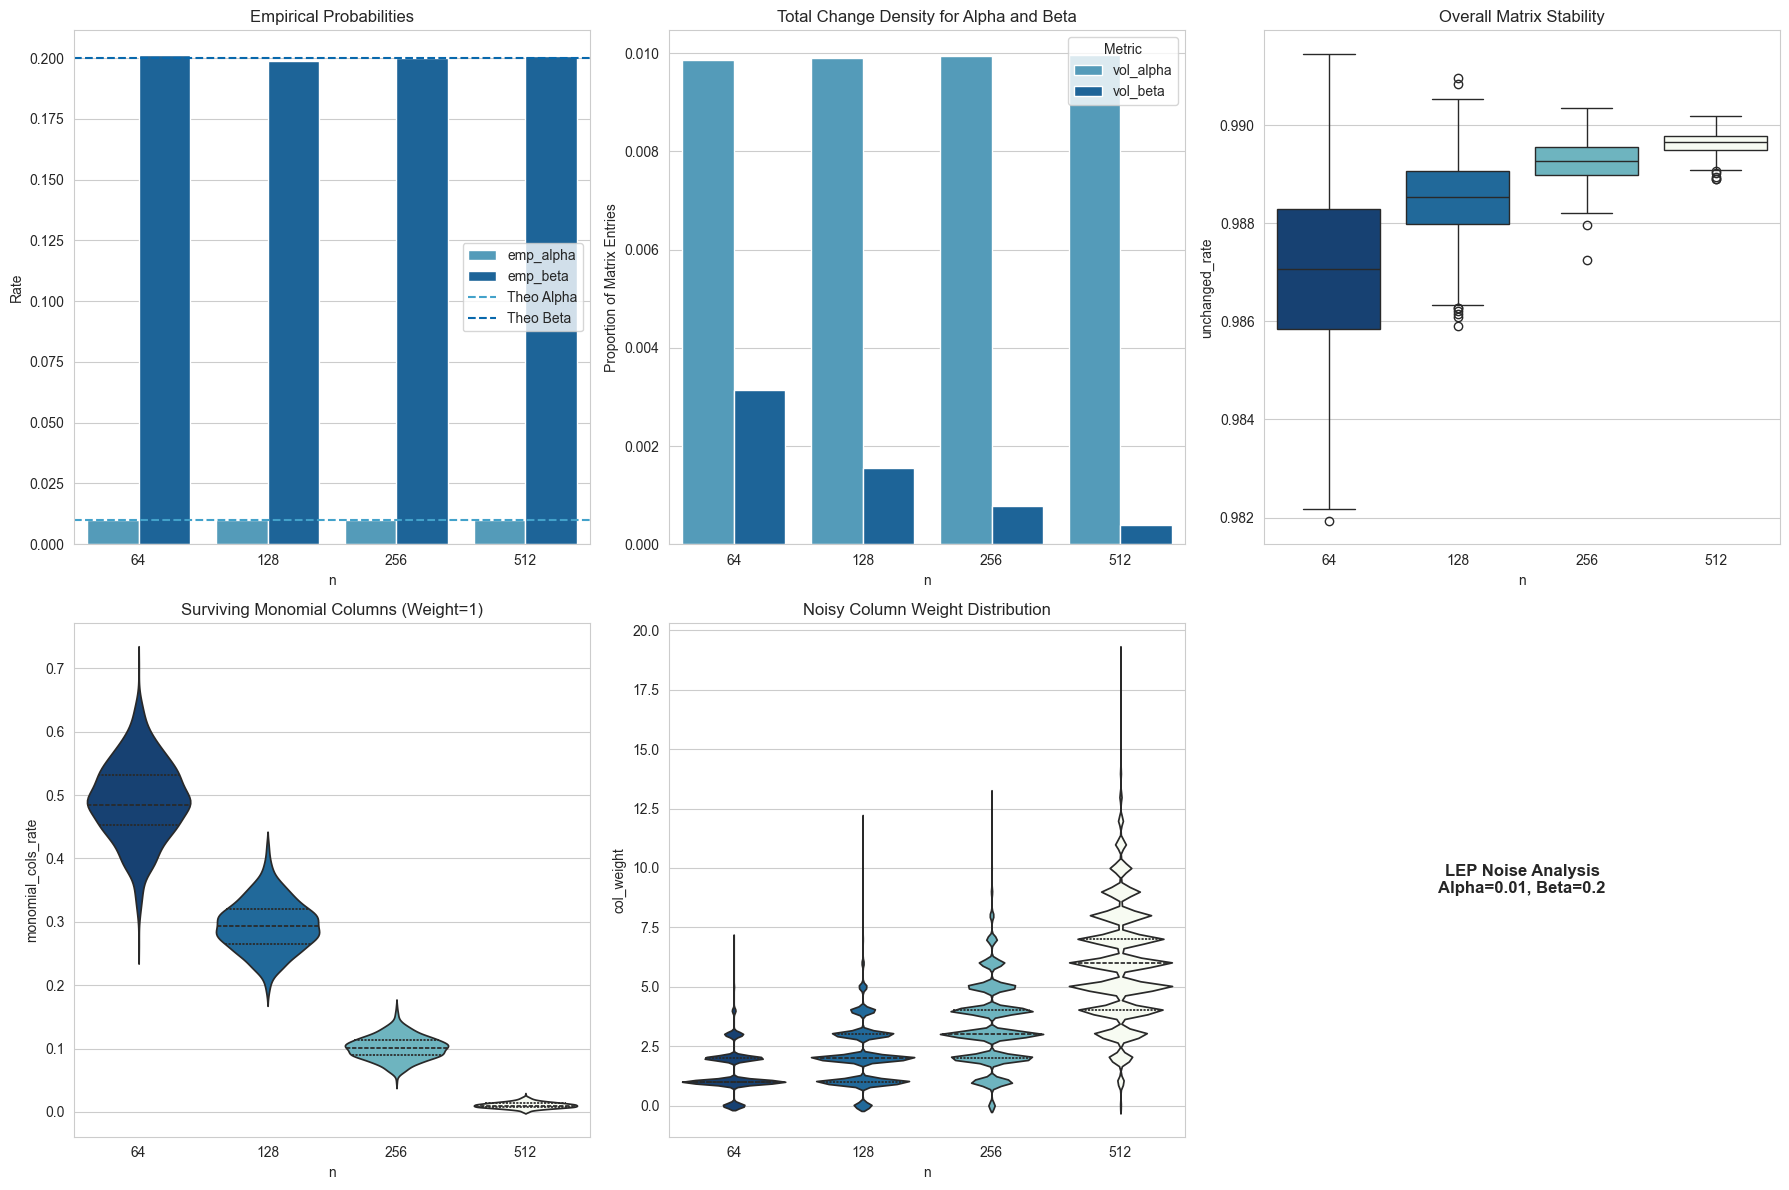

,n,emp_alpha,emp_beta,unchanged_rate,monomial_cols_rate,vol_alpha,vol_beta
0,64,0.010020,0.201328,0.986991,0.491828,0.009863,0.003146
1,128,0.009992,0.198867,0.988532,0.294430,0.009914,0.001554
2,256,0.009991,0.199898,0.989267,0.101684,0.009952,0.000781
3,512,0.009988,0.200740,0.989640,0.010936,0.009968,0.000392


In [40]:
data = generate_lep_data(NUM_SAMPLES, N_SIZES, Q_SIZES, ALPHA, BETA)
df_analysis = analyze_lep_data(data)

# compute average metrics by n
summary_df = df_analysis.groupby('n')[['emp_alpha', 'emp_beta', 'unchanged_rate', 'monomial_cols_rate', 'vol_alpha', 'vol_beta']].mean().reset_index()
summary_df

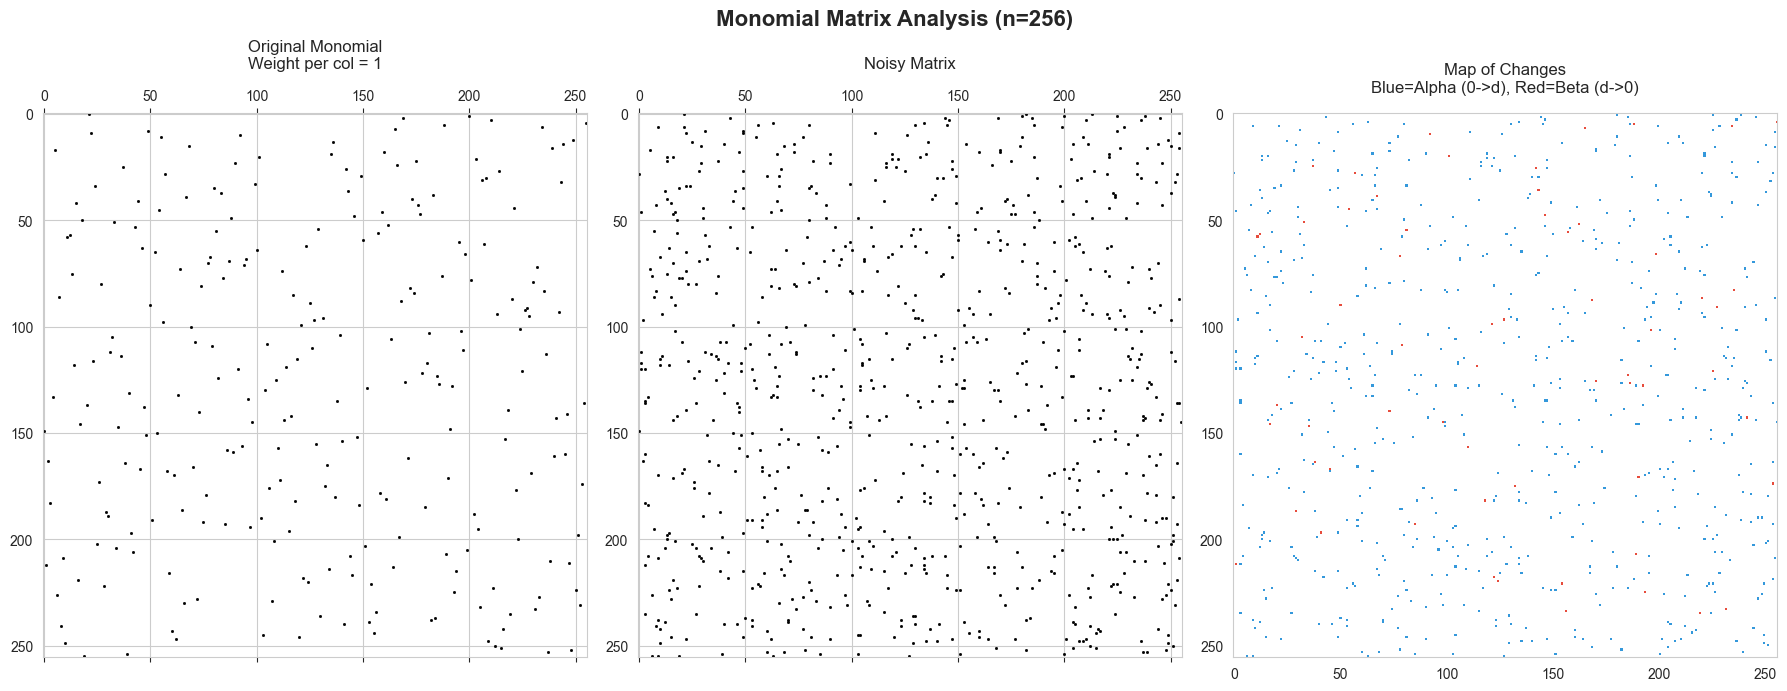

Statistics for example n=256:
 - Surviving monomial columns (Weight=1): 28 / 256
 - Columns that became zero (Weight=0): 3 / 256
 - 'Heavy' columns (Weight > 1): 225 / 256
Heaviest column weight: 8


In [54]:
matrix_id = 2026  # example index to visualize
visualize_matrix_changes(data[matrix_id][0], data[matrix_id][1], sample_index=0)

### Technical Analysis of LEP Noise Model

1. Empirical Probabilities vs. Noise Volume
  - **Individual Probability:** As seen in the *Empirical Probabilities* plot, the success rate of the noise per cell remains constant across all $n$. The probability of a non-zero element dropping to zero ($\beta = 0.2$) is **20 times higher** than a zero becoming a non-zero value ($\alpha = 0.01$).
  - **Alpha and Beta density:** Despite $\beta$ being higher, the *Total Change Density* plot reveals that $\alpha$-type changes (blue) dominate the matrix volume. This is because, in a monomial matrix of size $n$, there are only $n$ candidates for $\beta$ but $n^2 - n$ candidates for $\alpha$. For example, for $n=512$, we expect $\approx 102$ red changes (Beta) versus $\approx 2,616$ blue changes (Alpha). Thus, the "background noise" is visually and structurally more prevalent than the "signal loss" simply because there is more "space" (zeros) to corrupt.

2. Matrix Stability and Structural Degradation
  - **Overall Stability:** The *Overall Matrix Stability* increases with $n$. Since the majority of the matrix consists of zeros and $\alpha$ is very small, the probability that any given cell remains unchanged is very high ($\approx 99\%$). As the sample size $n^2$ grows.
  - **Monomial Survival:** The *Surviving Monomial Columns* plot shows a drastic decay as $n$ increases. As the matrix grows, the probability that a column retains its original "weight-1" structure becomes nearly zero. The columns are effectively changed by the additive noise of $\alpha$.

3. Distribution of Column Weights
  - **Hamming Weight Shift:** The *Noisy Column Weight Distribution* shows that while the original weight was exactly $1$, the noisy distribution centers around a higher mean. 
  - **Weight Variance:** For larger $n$, the "violins" become more elongated. This indicates that while the average weight per column is predictable, the variance increases, leading to some columns becoming "heavy" (high Hamming weight).

In general, it is NOT correct to assume that 0s are less likely to change than non-zeros.